***Week 4 Jupyter Notebook — Logistic Regression and Feature Scaling Instructions***

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data using the methods you have learned about in this course and in this program and draw interesting conclusions. 

For Week 4, include concepts such as logistic regression and feature scaling. This homework should be submitted for peer review in the assignment titled 4.3 Peer Review: Week 4 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In Week 7, you will compile your findings from your Jupyter Notebook homework into your Milestone One assignment for grading. For full instructions and the rubric for Milestone One, refer to the following link. 

# Week 4: Logistic regression, feature scaling, and data suitability

**Assignment coverage:** binary logistic regression; unscaled, standard, min–max, and robust scaling; train-only preprocessing; class imbalance; threshold selection; ROC/precision–recall/calibration; coefficient interpretation; conclusions. Each of the three datasets receives its own logistic-regression and scaling analysis.

**Expanded coverage:** this notebook applies the weekly methods independently to all three CSV files in `DATA`. Each dataset has its own response, preparation, model selection, diagnostics, and conclusions. Metrics with different outcomes or units must not be ranked against one another.

## Results across all three datasets

- **Loan_Default.csv** — recorded Status 1: test AUC **0.589**, average precision **0.328**, log loss **0.551**, test n = **29,734**; validation-selected threshold **0.23**.
- **accepted_2007_to_2018Q4.csv** — charged off among resolved 2015 36-month loans: test AUC **0.674**, average precision **0.244**, log loss **0.387**, test n = **4,800**; validation-selected threshold **0.15**.
- **bank_customers.csv** — checking account versus savings/CD: test AUC **0.500**, average precision **0.735**, log loss **0.942**, test n = **8**; validation-selected threshold **0.33**.

All three datasets now have independent logistic-regression and feature-scaling analyses. The positive classes are different and must not be interpreted as a common default outcome. The mortgage file has an undocumented status definition, LendingClub evaluation conditions on resolved 2015 36-month loans, and the bank target is checking account type in a very small date-valid subset. Scaling and threshold comparisons demonstrate method behavior; they do not justify lending decisions or deployment.

The prose describes this saved run. If inputs or parameters change, rerun all code and revise the narrative to match.

## A. Loan_Default.csv — independent analysis

## Context & methods

**Question:** How well can a deliberately restricted set of loan attributes
classify the recorded `Status` in `DATA/Loan_Default.csv`, and how does
scaling affect logistic regression?

### Key assumptions

`Status = 1` is the positive class. The filename suggests default, but no
supplied data dictionary verifies the outcome definition, performance window,
censoring, or measurement timing. We therefore report **recorded Status = 1**,
not a validated probability of future default. The dataset only contains 2019.
Unique record IDs are checked, but repeat borrowers cannot be ruled out.

Contract terms may only be known after application. Rate/spread/charges,
credit-bureau type, approval/workflow fields, and suspect missingness signals
are excluded. Gender and age are not model inputs. This is an educational
model; omission of sensitive attributes alone does not establish fairness.

A stratified 60%/20%/20% split preserves the class mix. Scalers and imputers
fit inside training CV. CV selects regularization, validation selects the
scaling approach and an illustrative F1 threshold, and the final test is
used once. Threshold selection has no assumed financial cost justification.

`bank_customers.csv` receives a separate checking-account classification analysis below. It has no loan-pricing or adverse-status response. SSNs are never loaded or displayed; the unrelated CSVs are never joined.

**Run:** install `requirements-notebooks.txt`, open from the repository or
parent workspace, and use **Restart Kernel → Run All**. All datasets remain
unchanged. The notebook does not depend on earlier weeks.

### 1. Set up a reproducible Python environment

Imports, a fixed random seed, readable charts, and explicit package versions make the analysis auditable.

In [1]:
from pathlib import Path
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

# A fixed seed and bounded numerical threads make the workflow repeatable.
SEED = 42
thread_limit = threadpool_limits(limits=1)
warnings.filterwarnings('error', category=ConvergenceWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'figure.dpi': 115,
                     'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'axes.axisbelow': True})
BLUE, ORANGE, GRAY = '#245E91', '#B96520', '#50545A'

# Support opening from the repository itself or its parent workspace.
data_candidates = [Path.cwd() / 'DATA',
                   Path.cwd() / 'Data-Science-Capstone-DX799' / 'DATA']
DATA_DIR = next((p for p in data_candidates if p.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Open this notebook from the repository or its parent; DATA is required.')
display(pd.Series({'Python': platform.python_version(), 'pandas': pd.__version__,
                   'NumPy': np.__version__, 'scikit-learn': sklearn.__version__,
                   'SciPy': scipy.__version__, 'seed': SEED}, name='Execution environment'))

Python          3.13.5
pandas           3.0.0
NumPy            2.4.1
scikit-learn     1.8.0
SciPy           1.17.0
seed                42
Name: Execution environment, dtype: object

### 2. Validate records and create stratified partitions

Keep target validation explicit. Do not impute outcomes or interpret missing outcomes as a negative class. Unique IDs support row-level splitting but cannot prove borrower independence.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score, log_loss,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
import time

loans = pd.read_csv(DATA_DIR / 'Loan_Default.csv')
assert loans['ID'].notna().all() and loans['ID'].is_unique
assert loans['Status'].notna().all() and set(loans['Status'].unique()) == {0, 1}
assert loans.duplicated().sum() == 0
y = loans['Status'].astype(int)
NUMERIC = ['loan_amount', 'income', 'Credit_Score', 'term']
CATEGORICAL = ['loan_type', 'loan_purpose', 'occupancy_type']
X = loans[NUMERIC + CATEGORICAL].copy()
for name in CATEGORICAL:
    X[name] = X[name].astype(object).where(X[name].notna(), np.nan)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
assert not (set(X_train.index) & set(X_valid.index) or set(X_dev.index) & set(X_test.index))
assert len(X_train) + len(X_valid) + len(X_test) == len(loans)
display(pd.DataFrame({'records': [len(loans), len(X_train), len(X_valid), len(X_test)],
    'Status 1 share': [y.mean(), y_train.mean(), y_valid.mean(), y_test.mean()]},
    index=['All records', 'Training', 'Validation', 'Test']))
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())
display(X_train[NUMERIC].agg(['min', 'median', 'max']))

,records,Status 1 share
All records,148670,0.2464
Training,89202,0.2464
Validation,29734,0.2465
Test,29734,0.2465


,Training missing (%)
loan_amount,0.0000
income,6.1725
Credit_Score,0.0000
term,0.0325
loan_type,0.0000
loan_purpose,0.0919
occupancy_type,0.0000


,loan_amount,income,Credit_Score,term
min,"16,500.0000",0.0000,500.0000,96.0000
median,"296,500.0000","5,760.0000",699.0000,360.0000
max,"3,346,500.0000","377,220.0000",900.0000,360.0000


### 3. Audit potential target leakage on training records

A missing field can almost reveal the outcome even when its numeric value is not used. Audit this pattern before interpreting high classification scores. The diagnostic below uses only the training partition.

,"Missing share, Status 0","Missing share, Status 1"
rate_of_interest,0.0000,0.9948
Interest_rate_spread,0.0000,1.0000
Upfront_charges,0.0277,0.9962
property_value,0.0000,0.4111
LTV,0.0000,0.4111
dtir1,0.0698,0.4445
income,0.0707,0.0342


Status,0,1,Status 1 share
credit_type,,,
CIB,24424,4559,0.1573
CRIF,21891,4307,0.1644
EQUI,0,9152,1.0000
EXP,20904,3965,0.1594


Training-only missing-rate rule accuracy: 99.8711%


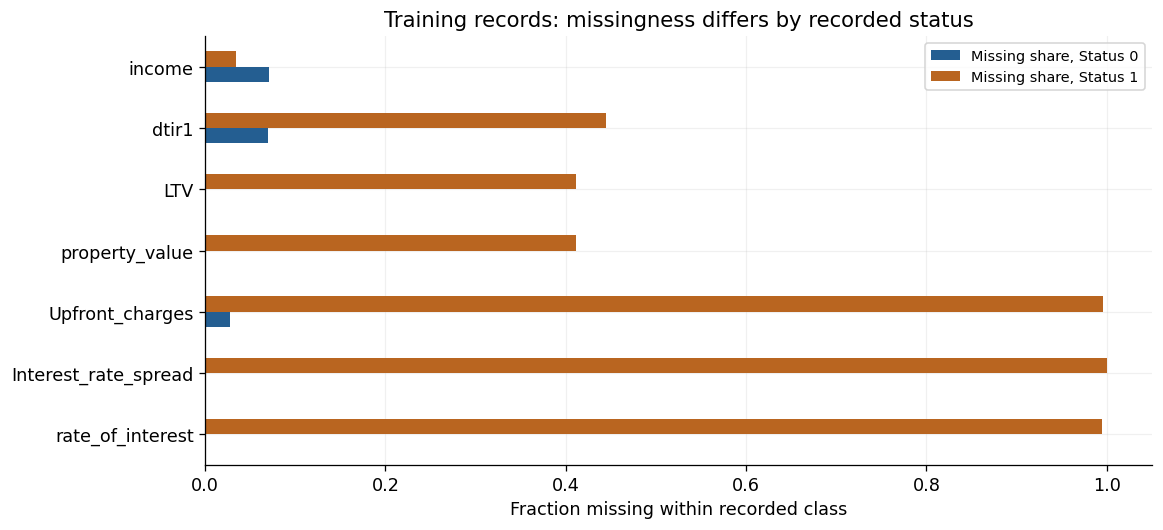

In [3]:
training_source = loans.loc[X_train.index]
audit_fields = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
                'property_value', 'LTV', 'dtir1', 'income']
missingness_by_status = training_source.groupby('Status')[audit_fields].agg(
    lambda values: values.isna().mean()).T
missingness_by_status.columns = ['Missing share, Status 0', 'Missing share, Status 1']
display(missingness_by_status)
bureau_status = pd.crosstab(training_source['credit_type'], training_source['Status'])
bureau_status['Status 1 share'] = bureau_status[1] / bureau_status[[0, 1]].sum(axis=1)
display(bureau_status)
# This diagnostic is NOT used as a predictor or a validated model.
missing_rate_rule = training_source['rate_of_interest'].isna().astype(int)
artifact_accuracy = accuracy_score(y_train, missing_rate_rule)
print(f'Training-only missing-rate rule accuracy: {artifact_accuracy:.4%}')

fig, ax = plt.subplots(figsize=(10, 4.5), layout='constrained')
missingness_by_status.plot.barh(ax=ax, color=[BLUE, ORANGE])
ax.set(xlim=(0, 1.05), xlabel='Fraction missing within recorded class', ylabel='',
       title='Training records: missingness differs by recorded status')
ax.legend(loc='upper right', fontsize=9)
plt.show()

A rule that predicts Status 1 whenever the interest rate is missing achieves **99.87% training accuracy**. This is a warning about the dataset's recording process, not evidence of an excellent default predictor. Rate, spread, charges, property/LTV/DTI fields, and credit-bureau type are excluded from this conservative demonstration because their timing or class-linked missingness needs verification. Even the remaining income missingness and contract attributes require provenance checks before operational use.

## Logistic regression and scaling logic

Logistic regression models
$\log[p/(1-p)] = \beta_0 + \sum_j\beta_jx_j$, so
$p = 1/(1+e^{-\eta})$. A coefficient's exponential is an odds ratio for
a one-unit change on the fitted input scale, holding other inputs fixed.
Odds ratios are not risk ratios and do not establish causality.

Standard scaling uses $(x-\mu)/\sigma$; min–max scaling uses
$(x-\min)/(\max-\min)$; robust scaling uses median/IQR. All parameters
are learned on training data. Extreme values can dominate standard/min–max
scaling; robust scaling does not itself remove outliers. Unseen values can
exceed the training min–max interval, which is acceptable here.

Unpenalized logistic predictions should be invariant to invertible scaling
if optimization converges. With L2 regularization, scaling also changes
how coefficients are penalized. We compare scalers at **C = 1** with the
same solver/budget, then tune C for the scaled approaches. Smaller C means
stronger regularization. Dummy indicators stay 0/1.

### 4. Compare scaling with a common solver budget

Record convergence explicitly rather than hiding warnings. An unconverged unscaled fit remains a diagnostic and cannot win model selection.

In [4]:
def classifier_pipeline(scaler, C=1.0):
    numeric_steps = [('impute', SimpleImputer(strategy='median'))]
    if scaler is not None:
        numeric_steps.append(('scale', clone(scaler)))
    prepare = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), NUMERIC),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL)], verbose_feature_names_out=False)
    return Pipeline([('prepare', prepare),
                     ('classify', LogisticRegression(C=C, solver='lbfgs',
                        max_iter=1000, tol=1e-6, random_state=SEED))])

scalers = {'Unscaled': None, 'Standard': StandardScaler(),
           'Min-max': MinMaxScaler(), 'Robust': RobustScaler()}
scaling_rows = []
fixed_models = {}
for name, scaler in scalers.items():
    estimator = classifier_pipeline(scaler)
    start_time = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        estimator.fit(X_train, y_train)
    converged = not any(issubclass(item.category, ConvergenceWarning) for item in caught)
    probabilities = estimator.predict_proba(X_valid)[:, 1]
    scaling_rows.append({'scaler': name, 'converged': converged,
        'solver iterations': int(estimator.named_steps['classify'].n_iter_[0]),
        'fit seconds (environment dependent)': time.perf_counter() - start_time,
        'Validation ROC AUC': roc_auc_score(y_valid, probabilities),
        'Validation log loss': log_loss(y_valid, probabilities)})
    fixed_models[name] = estimator
scaling_results = pd.DataFrame(scaling_rows).set_index('scaler')
display(scaling_results)
# Demonstrate that validation is transformed with training statistics only.
scaled_training = fixed_models['Standard'].named_steps['prepare'].named_transformers_['numeric'].transform(X_train[NUMERIC])
display(pd.DataFrame({'training scaled mean': scaled_training.mean(axis=0),
                      'training scaled SD': scaled_training.std(axis=0)}, index=NUMERIC))
assert np.allclose(scaled_training.mean(axis=0), 0, atol=1e-8)
assert np.allclose(scaled_training.std(axis=0), 1, atol=1e-8)

,converged,solver iterations,fit seconds (environment dependent),Validation ROC AUC,Validation log loss
scaler,,,,,
Unscaled,True,134,0.2252,0.5948,0.5516
Standard,True,43,0.1247,0.6006,0.5509
Min-max,True,65,0.1453,0.5941,0.5510
Robust,True,282,0.3707,0.6006,0.5509


,training scaled mean,training scaled SD
loan_amount,0.0000,1.0000
income,0.0000,1.0000
Credit_Score,-0.0000,1.0000
term,-0.0000,1.0000


### 5. Tune regularization and select a scaling approach

Use stratified training CV and log loss to tune probability quality. Select the scaler by independent validation log loss. Class weights stay unchanged so probabilities can be assessed against observed prevalence.

In [5]:
class_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
searches = {}
validation_rows = []
for name in ['Standard', 'Min-max', 'Robust']:
    search = GridSearchCV(classifier_pipeline(scalers[name]),
        {'classify__C': [0.01, 0.1, 1.0, 10.0]}, cv=class_cv,
        scoring='neg_log_loss', n_jobs=1, error_score='raise')
    search.fit(X_train, y_train)
    searches[name] = search
    probability = search.predict_proba(X_valid)[:, 1]
    validation_rows.append({'scaler': name, 'C': search.best_params_['classify__C'],
        'CV log loss': -search.best_score_, 'Validation log loss': log_loss(y_valid, probability),
        'Validation ROC AUC': roc_auc_score(y_valid, probability),
        'Validation average precision': average_precision_score(y_valid, probability)})
validation_results = pd.DataFrame(validation_rows).set_index('scaler')
display(validation_results.sort_values('Validation log loss'))
chosen_scaler = validation_results['Validation log loss'].idxmin()
selected_model = searches[chosen_scaler].best_estimator_
validation_probability = selected_model.predict_proba(X_valid)[:, 1]

,C,CV log loss,Validation log loss,Validation ROC AUC,Validation average precision
scaler,,,,,
Min-max,10.0000,0.5499,0.5508,0.5999,0.3311
Standard,1.0000,0.5499,0.5509,0.6006,0.3325
Robust,1.0000,0.5499,0.5509,0.6006,0.3325


### 6. Choose an illustrative decision threshold on validation loans

A probability model and a decision rule are different objects. Maximize validation F1 over a prespecified grid to illustrate the precision/recall tradeoff; actual lending decisions would require verified costs, constraints, and outcome definitions.

,threshold,precision,recall,F1
16,0.2100,0.2625,0.8593,0.4021
17,0.2200,0.2725,0.7818,0.4041
18,0.2300,0.2923,0.6706,0.4072
19,0.2400,0.3163,0.5413,0.3993
20,0.2500,0.3371,0.4284,0.3773


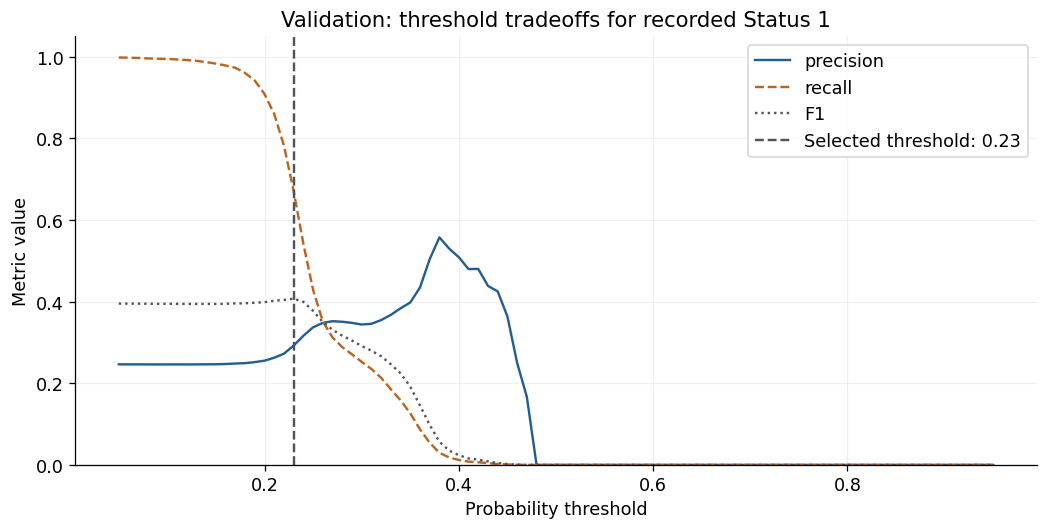

In [6]:
thresholds = np.linspace(0.05, 0.95, 91)
threshold_results = pd.DataFrame([{'threshold': threshold,
    'precision': precision_score(y_valid, validation_probability >= threshold, zero_division=0),
    'recall': recall_score(y_valid, validation_probability >= threshold, zero_division=0),
    'F1': f1_score(y_valid, validation_probability >= threshold, zero_division=0)}
    for threshold in thresholds])
chosen_threshold = float(threshold_results.loc[threshold_results['F1'].idxmax(), 'threshold'])
display(threshold_results.loc[(threshold_results['threshold'] - chosen_threshold).abs() < 0.021])
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
for name, color, style in [('precision', BLUE, '-'), ('recall', ORANGE, '--'), ('F1', GRAY, ':')]:
    ax.plot(threshold_results['threshold'], threshold_results[name], label=name, color=color, linestyle=style)
ax.axvline(chosen_threshold, color=GRAY, linestyle='--', label=f'Selected threshold: {chosen_threshold:.2f}')
ax.set(title='Validation: threshold tradeoffs for recorded Status 1',
       xlabel='Probability threshold', ylabel='Metric value', ylim=(0, 1.05))
ax.legend()
plt.show()

### 7. Evaluate once on the final test partition

Refit the chosen model on development data and freeze the validation-selected threshold. Report probability metrics, threshold metrics, and a constant-prevalence baseline. Accuracy alone is inadequate with class imbalance.

In [7]:
final_model = clone(selected_model).fit(X_dev, y_dev)
test_probability = final_model.predict_proba(X_test)[:, 1]
baseline_probability = np.full(len(y_test), y_dev.mean())

def probability_metrics(actual, probability):
    return {'ROC AUC': roc_auc_score(actual, probability),
            'Average precision': average_precision_score(actual, probability),
            'Log loss': log_loss(actual, probability),
            'Brier score': brier_score_loss(actual, probability)}

def threshold_metrics(actual, predicted):
    return {'Accuracy': accuracy_score(actual, predicted),
            'Balanced accuracy': balanced_accuracy_score(actual, predicted),
            'Precision': precision_score(actual, predicted, zero_division=0),
            'Recall': recall_score(actual, predicted, zero_division=0),
            'F1': f1_score(actual, predicted, zero_division=0)}

test_probability_results = pd.DataFrame({
    f'Logistic ({chosen_scaler})': probability_metrics(y_test, test_probability),
    'Training-prevalence baseline': probability_metrics(y_test, baseline_probability)}).T
test_decision_results = pd.DataFrame({
    'Logistic at 0.50': threshold_metrics(y_test, test_probability >= 0.50),
    f'Logistic at {chosen_threshold:.2f}': threshold_metrics(y_test, test_probability >= chosen_threshold),
    'Always Status 0': threshold_metrics(y_test, np.zeros(len(y_test), dtype=int))}).T
display(test_probability_results)
display(test_decision_results)
assert np.isfinite(test_probability).all() and ((test_probability >= 0) & (test_probability <= 1)).all()
final_confusion = confusion_matrix(y_test, test_probability >= chosen_threshold)
assert final_confusion.sum() == len(y_test)

# Paired loan-level bootstrap: conditional uncertainty for this fitted model.
rng = np.random.default_rng(SEED)
auc_draws = []
actual = y_test.to_numpy()
for _ in range(300):
    index = rng.integers(0, len(y_test), len(y_test))
    auc_draws.append(roc_auc_score(actual[index], test_probability[index]))
auc_interval = np.quantile(auc_draws, [0.025, 0.975])
print(f'Test ROC AUC, loan-bootstrap 95% interval: [{auc_interval[0]:.3f}, {auc_interval[1]:.3f}]')

,ROC AUC,Average precision,Log loss,Brier score
Logistic (Min-max),0.5890,0.3276,0.5512,0.1824
Training-prevalence baseline,0.5000,0.2465,0.5584,0.1857


,Accuracy,Balanced accuracy,Precision,Recall,F1
Logistic at 0.50,0.7535,0.5000,0.0000,0.0000,0.0000
Logistic at 0.23,0.5163,0.5590,0.2860,0.6430,0.3959
Always Status 0,0.7535,0.5000,0.0000,0.0000,0.0000


Test ROC AUC, loan-bootstrap 95% interval: [0.581, 0.596]


**Observed decision behavior.** At the conventional **0.50** threshold, this test model predicts no positive records: accuracy is **75.35%**, but positive-class recall is **0%**. Lowering the threshold to the validation-selected **0.23** raises recall to **64.3%** while lowering accuracy to **51.63%**. The threshold trades errors; it does not make the weak ranking performance disappear. Test log loss improves only from **0.5584** for the prevalence baseline to **0.5512** for logistic regression.

### 8. Inspect discrimination, calibration, and classification errors

ROC measures ranking across thresholds; precision–recall emphasizes the positive class. Calibration compares mean predicted probabilities with observed fractions in quantile bins. The reliability curve is a diagnostic, not proof of calibration.

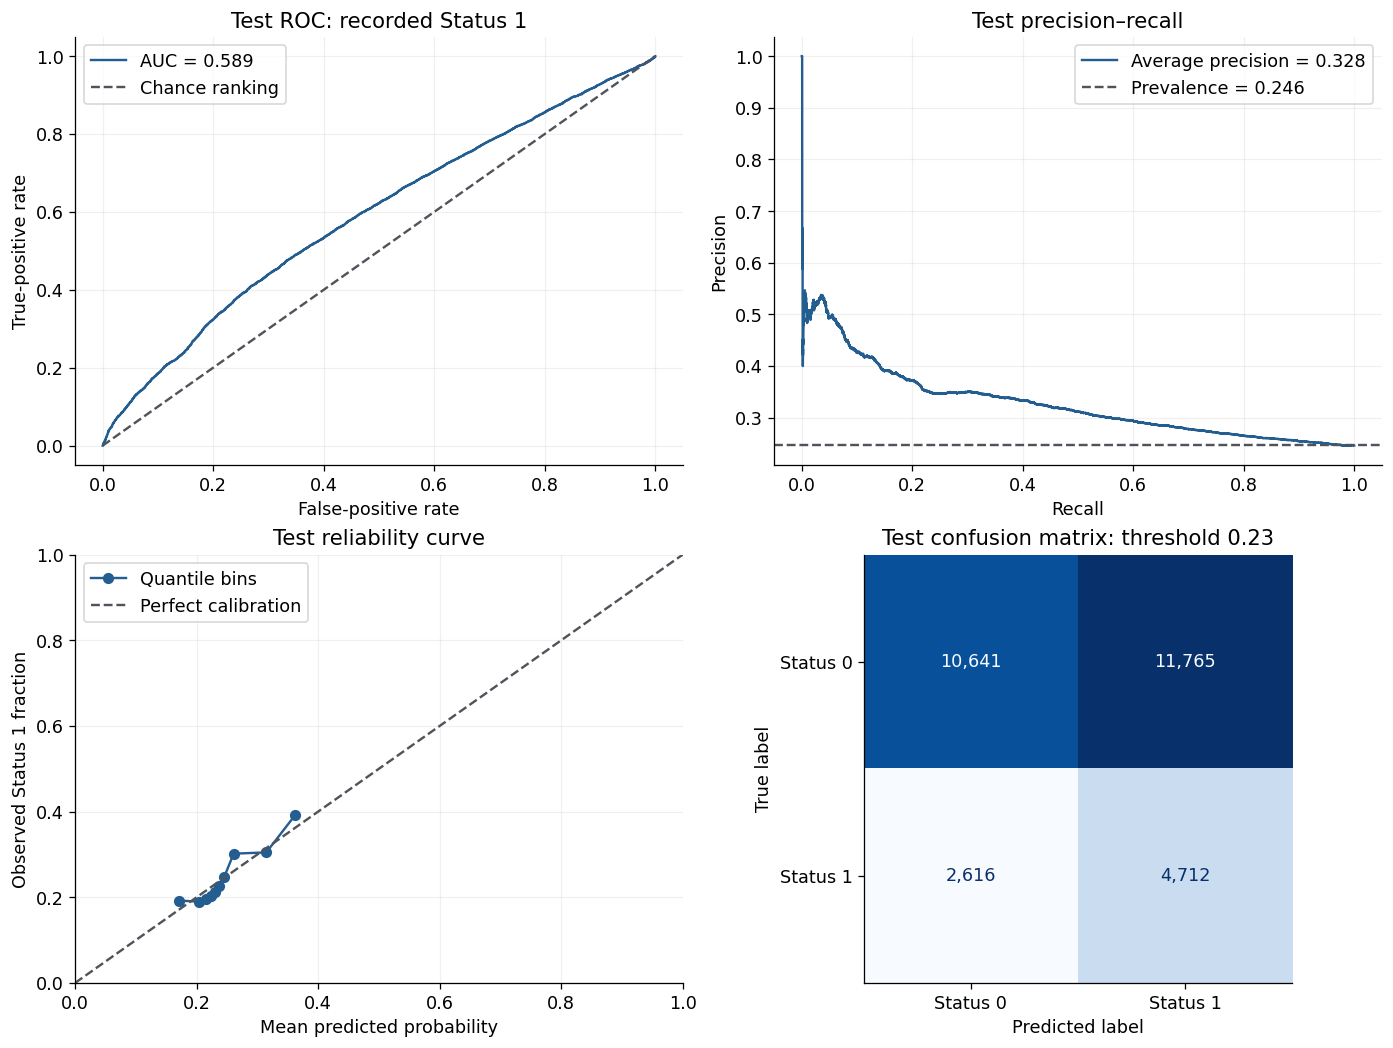

,records,predicted_probability,observed_Status_1_fraction
probability_bin,,,
"(-0.0009999174, 0.196]",2974,0.1706,0.1923
"(0.196, 0.211]",2973,0.2041,0.1897
"(0.211, 0.22]",2973,0.2156,0.1958
"(0.22, 0.227]",2974,0.2237,0.2021
"(0.227, 0.234]",2973,0.2304,0.2133
"(0.234, 0.241]",2973,0.2373,0.2274
"(0.241, 0.25]",2974,0.2452,0.2465
"(0.25, 0.28]",2973,0.2609,0.3017
"(0.28, 0.339]",2973,0.3146,0.3047


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout='constrained')
false_positive, true_positive, _ = roc_curve(y_test, test_probability)
axes[0, 0].plot(false_positive, true_positive, color=BLUE, label=f'AUC = {roc_auc_score(y_test, test_probability):.3f}')
axes[0, 0].plot([0, 1], [0, 1], '--', color=GRAY, label='Chance ranking')
axes[0, 0].set(title='Test ROC: recorded Status 1', xlabel='False-positive rate', ylabel='True-positive rate')
axes[0, 0].legend()
precision, recall, _ = precision_recall_curve(y_test, test_probability)
axes[0, 1].plot(recall, precision, color=BLUE,
                label=f'Average precision = {average_precision_score(y_test, test_probability):.3f}')
axes[0, 1].axhline(y_test.mean(), color=GRAY, linestyle='--', label=f'Prevalence = {y_test.mean():.3f}')
axes[0, 1].set(title='Test precision–recall', xlabel='Recall', ylabel='Precision')
axes[0, 1].legend()
observed_fraction, mean_prediction = calibration_curve(y_test, test_probability, n_bins=10, strategy='quantile')
axes[1, 0].plot(mean_prediction, observed_fraction, 'o-', color=BLUE, label='Quantile bins')
axes[1, 0].plot([0, 1], [0, 1], '--', color=GRAY, label='Perfect calibration')
axes[1, 0].set(title='Test reliability curve', xlabel='Mean predicted probability',
               ylabel='Observed Status 1 fraction', xlim=(0, 1), ylim=(0, 1))
axes[1, 0].legend()
ConfusionMatrixDisplay(final_confusion, display_labels=['Status 0', 'Status 1']).plot(
    ax=axes[1, 1], cmap='Blues', colorbar=False, values_format=',d')
axes[1, 1].grid(False)
axes[1, 1].set_title(f'Test confusion matrix: threshold {chosen_threshold:.2f}')
plt.show()
calibration_table = pd.DataFrame({'predicted': test_probability, 'observed': y_test.to_numpy()})
calibration_table['probability_bin'] = pd.qcut(calibration_table['predicted'], 10, duplicates='drop')
calibration_summary = calibration_table.groupby('probability_bin', observed=True).agg(
    records=('observed', 'size'), predicted_probability=('predicted', 'mean'),
    observed_Status_1_fraction=('observed', 'mean'))
display(calibration_summary)

### 9. Interpret standardized coefficients and reference categories

Use the converged standard-scaled C = 1 training model for a common, explicit coefficient scale. Numeric odds ratios refer to one training SD; categorical odds ratios compare with the printed reference. These are conditional associations.

In [9]:
interpretation_model = fixed_models['Standard']
assert scaling_results.loc['Standard', 'converged']
prepare = interpretation_model.named_steps['prepare']
coefficient_table = pd.DataFrame({
    'feature': prepare.get_feature_names_out(),
    'log-odds coefficient': interpretation_model.named_steps['classify'].coef_[0]})
coefficient_table['odds ratio'] = np.exp(coefficient_table['log-odds coefficient'])
coefficient_table['comparison'] = ['one training SD' if name in NUMERIC else 'vs reference level'
                                   for name in coefficient_table['feature']]
display(coefficient_table.sort_values('log-odds coefficient'))
encoder = prepare.named_transformers_['categorical'].named_steps['encode']
display(pd.Series({name: values[0] for name, values in zip(CATEGORICAL, encoder.categories_)},
                   name='Reference category'))

,feature,log-odds coefficient,odds ratio,comparison
9,occupancy_type_pr,-0.5269,0.5904,vs reference level
1,income,-0.3079,0.7350,one training SD
8,loan_purpose_p4,-0.1219,0.8852,vs reference level
7,loan_purpose_p3,-0.0696,0.9328,vs reference level
10,occupancy_type_sr,-0.0599,0.9418,vs reference level
3,term,-0.0594,0.9424,one training SD
2,Credit_Score,0.0097,1.0098,one training SD
0,loan_amount,0.0891,1.0932,one training SD
5,loan_type_type3,0.1048,1.1104,vs reference level
6,loan_purpose_p2,0.2868,1.3321,vs reference level


loan_type         type1
loan_purpose         p1
occupancy_type       ir
Name: Reference category, dtype: str

### Dataset conclusions — Loan_Default.csv

1. **Min-max scaling** was selected by validation log loss. On **29,734** final-test records, ROC AUC was **0.589** (loan-bootstrap 95% interval **0.581–0.596**), average precision **0.328**, and log loss **0.551**. The positive-class prevalence was **24.6%**.
2. The validation-selected threshold was **0.23**. Test precision was **28.6%**, recall **64.3%**, and F1 **0.396**. The confusion matrix contains **11,765 false positives** and **2,616 false negatives**. Threshold choice changes these errors without changing the underlying probabilities.
3. The unscaled fit **converged** within the common solver budget. Standard scaling required **43** iterations versus **134** unscaled. Scaling affects optimization and L2 penalization; runtime depends on the environment.
4. A missing-interest-rate rule scored **99.87% training accuracy**, exposing a recording-process artifact. Excluding that signal makes the exercise more defensible, but does not establish that the remaining model forecasts default.

**Capstone implication:** the recorded-status classifier offers modest educational evidence about associations and scaling. Before any operational claim, obtain the target definition and observation window, verify feature availability at decision time, audit remaining missingness and subgroup performance, and validate on a later cohort. The bootstrap interval is conditional on these fitted models and assumes independent records; it does not resolve these source limitations.

### Shared tools for the additional independent analyses

Reuse transparent pipeline-building code, not fitted objects or results. Dataset B and Dataset C each reload their own file, redefine the response, reserve their own evaluation data, and fit every method afresh.

In [10]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
    brier_score_loss, accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

class ExtraTerms(TransformerMixin, BaseEstimator):
    """Retain parents; append numeric squares and prespecified interactions."""
    def __init__(self, numeric_count=1, mode='linear'):
        self.numeric_count = numeric_count
        self.mode = mode

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        values = np.asarray(X)
        pieces = [values]
        if self.mode in ('quadratic', 'interaction'):
            pieces.append(values[:, :self.numeric_count] ** 2)
        if self.mode == 'interaction':
            # Interact the first continuous feature with each remaining numeric
            # predictor and category indicator. Do not square 0/1 indicators.
            pieces.append(values[:, [0]] * values[:, 1:])
        return np.column_stack(pieces)

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        result = names.copy()
        if self.mode in ('quadratic', 'interaction'):
            result += [f'{name} squared' for name in names[:self.numeric_count]]
        if self.mode == 'interaction':
            result += [f'{names[0]} × {name}' for name in names[1:]]
        return np.asarray(result, dtype=object)

def extra_preprocessor(numeric, categorical, scaler='standard'):
    """No preparation is learned from validation/test rows."""
    scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(),
               'robust': RobustScaler(), 'none': None}
    transformers = []
    if numeric:
        steps = [('impute', SimpleImputer(strategy='median'))]
        if scalers[scaler] is not None:
            steps.append(('scale', scalers[scaler]))
        transformers.append(('num', Pipeline(steps), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def extra_regressor(numeric, categorical, mode='linear', estimator=None, scale_all=False):
    steps = [('prepare', extra_preprocessor(numeric, categorical)),
             ('terms', ExtraTerms(len(numeric), mode))]
    if scale_all:
        steps.append(('scale_all', StandardScaler()))
    steps.append(('model', LinearRegression() if estimator is None else estimator))
    return Pipeline(steps)

def extra_split(X, y, groups=None, classification=False):
    """Use a row split for loans and account-group separation for bank records."""
    if groups is None:
        development, test = train_test_split(np.arange(len(X)), test_size=0.20,
            random_state=SEED, stratify=y if classification else None)
        train, valid = train_test_split(development, test_size=0.25, random_state=SEED,
            stratify=y.iloc[development] if classification else None)
        cv = (StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
              if classification else KFold(n_splits=3, shuffle=True, random_state=SEED))
        folds = list(cv.split(X.iloc[train], y.iloc[train]))
    else:
        development, test = next(GroupShuffleSplit(n_splits=1, test_size=0.20,
            random_state=SEED).split(X, y, groups))
        train_local, valid_local = next(GroupShuffleSplit(n_splits=1, test_size=0.25,
            random_state=SEED).split(X.iloc[development], y.iloc[development], groups.iloc[development]))
        train, valid = development[train_local], development[valid_local]
        # Do not split records from the same account across CV folds either.
        folds = list(GroupKFold(n_splits=3).split(X.iloc[train], y.iloc[train], groups.iloc[train]))
        sets = [set(groups.iloc[index]) for index in [train, valid, test]]
        assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
    assert len(set(train) | set(valid) | set(test)) == len(X)
    if classification:
        for index in [train, valid, test]:
            assert y.iloc[index].nunique() == 2, 'Both classes are required in every evaluation split.'
        for fit, holdout in folds:
            assert y.iloc[train].iloc[fit].nunique() == 2
            assert y.iloc[train].iloc[holdout].nunique() == 2
    return train, valid, test, development, folds

def extra_metrics(actual, prediction):
    prediction = np.asarray(prediction).ravel()
    return {'RMSE': np.sqrt(mean_squared_error(actual, prediction)),
            'MAE': mean_absolute_error(actual, prediction), 'R²': r2_score(actual, prediction)}

def extra_vif(frame):
    values = StandardScaler().fit_transform(frame)
    rows = []
    for j, name in enumerate(frame.columns):
        if np.std(values[:, j]) < 1e-12:
            value = np.inf
        elif len(frame.columns) == 1:
            value = 1.0
        else:
            r_squared = LinearRegression().fit(np.delete(values, j, axis=1), values[:, j]).score(
                np.delete(values, j, axis=1), values[:, j])
            value = np.inf if 1 - r_squared < 1e-10 else 1 / (1 - r_squared)
        rows.append({'feature': name, 'VIF': value})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

# Store results separately so later sections cannot overwrite another dataset's evidence.
dataset_results = []

### Preserve Dataset A’s verified results

Keep a separate named result record before beginning another dataset.

In [11]:
primary_scores = test_probability_results.iloc[0]
dataset_results.append({'dataset':'Loan_Default.csv','outcome':'recorded Status 1',
    'training n':len(y_train),'test n':len(y_test),'model':f'Logistic ({chosen_scaler})',
    'ROC AUC':primary_scores['ROC AUC'],'Average precision':primary_scores['Average precision'],
    'Log loss':primary_scores['Log loss'], 'threshold':chosen_threshold,
    'positive share':y_test.mean()})

## B. accepted_2007_to_2018Q4.csv — independent analysis

**Response:** Charged Off = 1 versus Fully Paid = 0 among resolved 2015 loans with
36-month terms. The CSV is scanned completely and sampled uniformly by random priorities.
Shorter, older loans reduce maturity problems, but the response remains conditional on
resolved status at the unknown extract cutoff. Current, late, grace-period, and other
statuses are excluded and counted, never reclassified as nondefaults.

Predictors use origination/application attributes. Interest rate, grade, installment,
recovery, outstanding balance, latest credit score, and payment fields are excluded.
Status is used only to construct the outcome. Random evaluation within this historical
cohort is not an out-of-time test, and a usable borrower key is not available here.
The prediction task differs from both mortgage Status and bank account type.

### B1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [12]:
dataset_name = 'accepted_2007_to_2018Q4.csv'
outcome_label = 'charged off among resolved 2015 36-month loans'
USECOLS = ['id', 'loan_amnt', 'annual_inc', 'fico_range_low', 'fico_range_high',
           'dti', 'revol_util', 'open_acc', 'emp_length', 'earliest_cr_line',
           'issue_d', 'loan_status', 'term', 'home_ownership', 'purpose', 'verification_status']
rng = np.random.default_rng(SEED)
frame = pd.DataFrame()
all_rows = vintage_rows = short_term_rows = eligible_rows = 0
status_counts = pd.Series(dtype='int64')
for chunk in pd.read_csv(DATA_DIR / dataset_name, usecols=USECOLS, chunksize=150_000, low_memory=False):
    all_rows += len(chunk)
    cohort = chunk.loc[chunk['issue_d'].astype('str').str.endswith('2015')].copy()
    vintage_rows += len(cohort)
    cohort = cohort.loc[cohort['term'].str.strip().eq('36 months')]
    short_term_rows += len(cohort)
    status_counts = status_counts.add(cohort['loan_status'].value_counts(), fill_value=0)
    cohort = cohort.loc[cohort['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
    eligible_rows += len(cohort)
    if len(cohort):
        cohort['_priority'] = rng.random(len(cohort))
        frame = pd.concat([frame, cohort.nsmallest(24_000, '_priority')]).nsmallest(24_000, '_priority')
frame = frame.drop(columns='_priority').reset_index(drop=True)
assert frame['id'].notna().all() and frame['id'].is_unique
display(pd.Series({'source rows': all_rows, '2015 records': vintage_rows,
    '2015 36-month records': short_term_rows, 'resolved eligible records': eligible_rows,
    'excluded unresolved/other statuses': short_term_rows - eligible_rows,
    'uniform sample': len(frame)}, name='Resolved-outcome cohort'))
display(status_counts.astype(int).rename('2015 36-month records').to_frame())
X = pd.DataFrame({
    'log_loan_amount': np.log1p(frame['loan_amnt'].where(frame['loan_amnt'] > 0)),
    'log_annual_income': np.log1p(frame['annual_inc'].where(frame['annual_inc'] >= 0)),
    'fico_mid': (frame['fico_range_low'] + frame['fico_range_high']) / 2,
    'dti': frame['dti'].where(frame['dti'] >= 0),
    'revol_util': frame['revol_util'].where(frame['revol_util'] >= 0),
    'open_acc': frame['open_acc']})
numeric = list(X.columns)
categorical = ['home_ownership', 'purpose', 'verification_status']
for name in categorical:
    X[name] = frame[name].astype(object).where(frame[name].notna(), np.nan)
y = frame['loan_status'].eq('Charged Off').astype(int)
groups = None

source rows                           2260701
2015 records                           421095
2015 36-month records                  283173
resolved eligible records              283026
excluded unresolved/other statuses        147
uniform sample                          24000
Name: Resolved-outcome cohort, dtype: int64

,2015 36-month records
loan_status,
Charged Off,42132
Current,72
Fully Paid,240894
In Grace Period,9
Late (16-30 days),5
Late (31-120 days),61


### B2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [13]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=True)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean
training,14400,0.1426
validation,4800,0.1425
test,4800,0.1427


,Training missing (%)
log_loan_amount,0.0000
log_annual_income,0.0000
fico_mid,0.0000
dti,0.0000
revol_util,0.0347
open_acc,0.0000
home_ownership,0.0000
purpose,0.0000
verification_status,0.0000


### B3. Inspect this dataset’s class balance and training predictors

Use the declared binary outcome for this CSV. Compare training-class counts and the first predictor’s distributions, while keeping later model fitting separate from evaluation outcomes. The positive class is named in the chart.

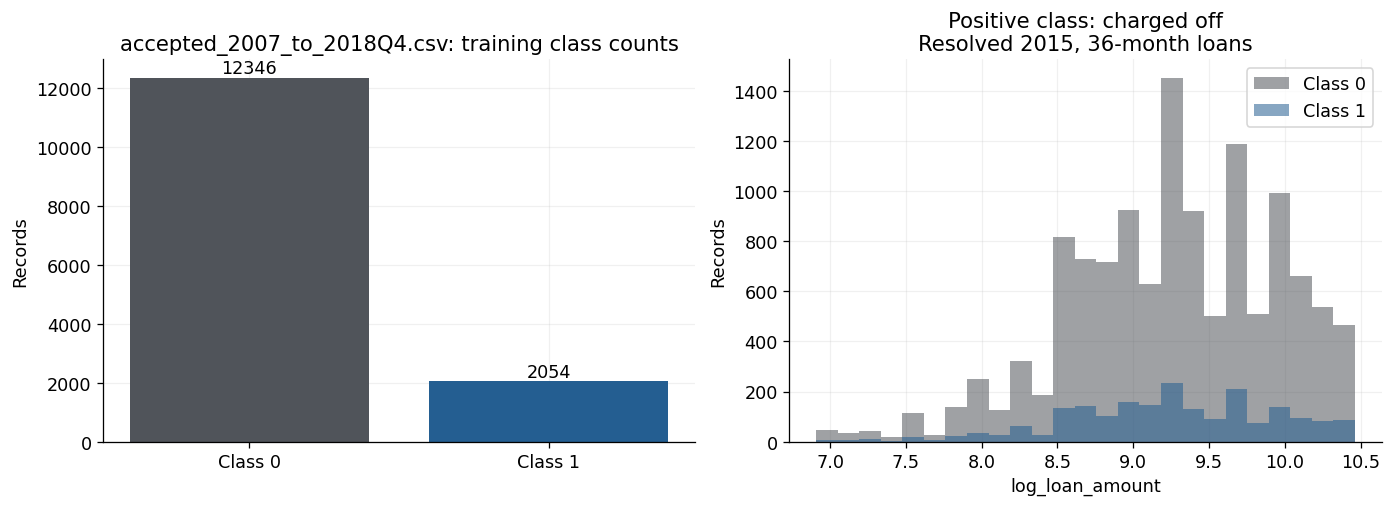

,log_loan_amount,log_annual_income,fico_mid,dti,revol_util,open_acc
min,6.9088,8.6997,662.0000,0.0000,0.0000,1.0000
median,9.2104,11.0349,687.0000,17.9200,51.7000,11.0000
max,10.4631,13.9978,847.5000,46.7100,132.5000,47.0000


In [14]:
counts=y_train.value_counts().reindex([0,1],fill_value=0)
fig,axes=plt.subplots(1,2,figsize=(12,4.3),layout='constrained')
axes[0].bar(['Class 0','Class 1'],counts.to_numpy(),color=[GRAY,BLUE])
for j,count in enumerate(counts):axes[0].text(j,count,str(count),ha='center',va='bottom')
axes[0].set(title=f'{dataset_name}: training class counts',ylabel='Records')
bin_edges = np.histogram_bin_edges(X_train[numeric[0]].dropna(), bins=8 if len(y_train)<100 else 25)
positive_title = ('Positive class: charged off\nResolved 2015, 36-month loans' if dataset_name.startswith('accepted')
                  else 'Positive class: checking\nComparator: savings or CD')
for label,color in [(0,GRAY),(1,BLUE)]:
    axes[1].hist(X_train.loc[y_train.eq(label),numeric[0]],bins=bin_edges,
                 alpha=0.55,color=color,label=f'Class {label}')
axes[1].set(title=positive_title,xlabel=numeric[0],ylabel='Records')
axes[1].legend()
plt.show()
display(X_train[numeric].agg(['min','median','max']))

### B4. Fit logistic regression with four scaling choices

Repeat unscaled, standard, min–max, and robust scaling at the same C = 1, solver, tolerance, and iteration budget. Scaling changes numerical conditioning and the meaning of the L2 penalty. Record convergence rather than suppressing it.

**Category warning:** the saved validation run contains a home-ownership category that was absent from training. The encoder uses `handle_unknown="ignore"` so it can produce a prediction without learning categories from validation data. With a dropped reference level, an unseen category receives an all-zero indicator block and is therefore indistinguishable from the reference category. The warning is retained; performance for such rare categories is not separately established.

In [15]:
import time
def extra_classifier(scaler,C=1.0):
    return Pipeline([('prepare',extra_preprocessor(numeric,categorical,scaler)),
        ('model',LogisticRegression(C=C,solver='lbfgs',max_iter=3000,tol=1e-6,random_state=SEED))])
fixed={}
scale_rows=[]
for scaler in ['none','standard','minmax','robust']:
    estimator=extra_classifier(scaler)
    started=time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always',ConvergenceWarning)
        estimator.fit(X_train,y_train)
    converged=not any(issubclass(item.category,ConvergenceWarning) for item in caught)
    probability=estimator.predict_proba(X_valid)[:,1]
    fixed[scaler]=estimator
    scale_rows.append({'scaler':scaler,'converged':converged,
        'iterations':int(estimator.named_steps['model'].n_iter_[0]),
        'fit seconds':time.perf_counter()-started,'validation log loss':log_loss(y_valid,probability),
        'validation AUC':roc_auc_score(y_valid,probability)})
scale_results=pd.DataFrame(scale_rows).set_index('scaler')
display(scale_results)
standardized=fixed['standard'].named_steps['prepare'].transform(X_train)[:,:len(numeric)]
display(pd.DataFrame({'standardized training mean':standardized.mean(axis=0),
                      'standardized training SD':standardized.std(axis=0)},index=numeric))
assert np.allclose(standardized.mean(axis=0),0,atol=1e-8)
assert np.allclose(standardized.std(axis=0),1,atol=1e-8)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in co

,converged,iterations,fit seconds,validation log loss,validation AUC
scaler,,,,,
none,False,3000,0.6452,0.3951,0.6384
standard,True,117,0.0391,0.3946,0.6402
minmax,True,96,0.0352,0.3946,0.6402
robust,True,92,0.0366,0.3946,0.6402


,standardized training mean,standardized training SD
log_loan_amount,0.0000,1.0000
log_annual_income,-0.0000,1.0000
fico_mid,0.0000,1.0000
dti,-0.0000,1.0000
revol_util,-0.0000,1.0000
open_acc,0.0000,1.0000


### B5. Tune regularization within this dataset’s training folds

Training CV selects C for each scaled pipeline; validation log loss selects the scaler. Bank folds preserve account groups. Do not compare the numeric C or classification scores with another dataset as if its target were the same.

In [16]:
searches={}
rows=[]
for scaler in ['standard','minmax','robust']:
    search=GridSearchCV(extra_classifier(scaler),{'model__C':[0.01,0.1,1.0,10.0]},
        cv=folds,scoring='neg_log_loss',n_jobs=1,error_score='raise').fit(X_train,y_train)
    searches[scaler]=search
    probability=search.predict_proba(X_valid)[:,1]
    rows.append({'scaler':scaler,'C':search.best_params_['model__C'],
        'CV log loss':-search.best_score_,'validation log loss':log_loss(y_valid,probability),
        'validation AUC':roc_auc_score(y_valid,probability),
        'validation average precision':average_precision_score(y_valid,probability)})
validation=pd.DataFrame(rows).set_index('scaler')
display(validation.sort_values('validation log loss'))
selected_scaler=validation['validation log loss'].idxmin()
chosen_model=searches[selected_scaler].best_estimator_
validation_probability=chosen_model.predict_proba(X_valid)[:,1]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,C,CV log loss,validation log loss,validation AUC,validation average precision
scaler,,,,,
standard,0.1000,0.3932,0.3945,0.6403,0.2120
robust,0.1000,0.3932,0.3945,0.6403,0.2120
minmax,1.0000,0.3936,0.3946,0.6402,0.2107


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### B6. Select a threshold from this dataset’s validation records

Maximize validation F1 over a prespecified threshold grid. This is an illustrative precision/recall tradeoff, not an optimized financial or customer-contact policy. With only a few bank validation records, the curve changes in large discrete steps.

,threshold,precision,recall,F1
8,0.1300,0.1836,0.7091,0.2917
9,0.1400,0.1956,0.6579,0.3015
10,0.1500,0.2061,0.6082,0.3079
11,0.1600,0.2126,0.5409,0.3053
12,0.1700,0.2235,0.4898,0.3069


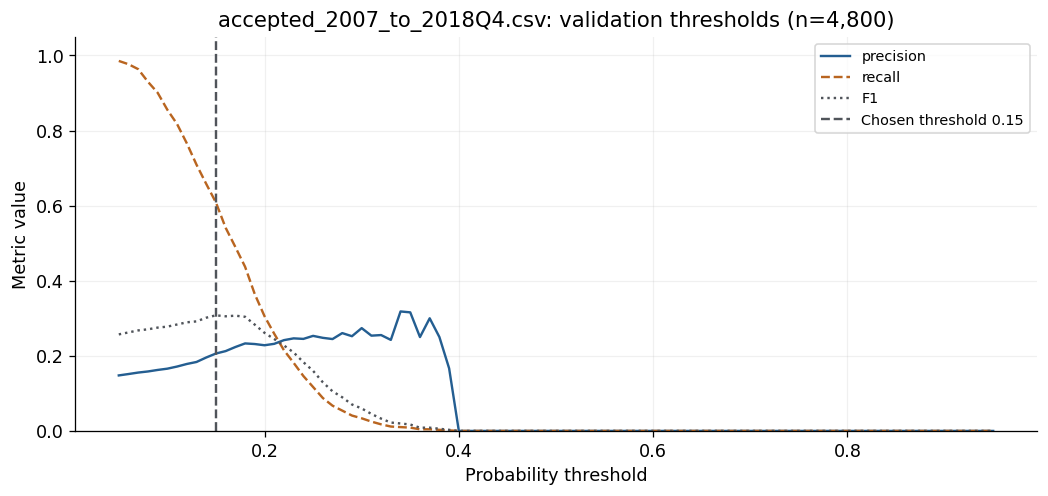

In [17]:
threshold_table=pd.DataFrame([{'threshold':t,
    'precision':precision_score(y_valid,validation_probability>=t,zero_division=0),
    'recall':recall_score(y_valid,validation_probability>=t,zero_division=0),
    'F1':f1_score(y_valid,validation_probability>=t,zero_division=0)}
    for t in np.linspace(0.05,0.95,91)])
threshold=float(threshold_table.loc[threshold_table.F1.idxmax(),'threshold'])
display(threshold_table.loc[(threshold_table.threshold-threshold).abs()<0.021])
fig,ax=plt.subplots(figsize=(9,4.2),layout='constrained')
for name,color,style in [('precision',BLUE,'-'),('recall',ORANGE,'--'),('F1',GRAY,':')]:
    ax.plot(threshold_table.threshold,threshold_table[name],label=name,color=color,linestyle=style)
ax.axvline(threshold,color=GRAY,linestyle='--',label=f'Chosen threshold {threshold:.2f}')
ax.set(title=f'{dataset_name}: validation thresholds (n={len(y_valid):,})',
       xlabel='Probability threshold',ylabel='Metric value',ylim=(0,1.05))
ax.legend(fontsize=9)
plt.show()

### B7. Evaluate probabilities and classifications on this dataset’s test set

Refit the selected pipeline on development data and freeze the validation threshold. Compare against development-prevalence probabilities and the development-majority class. The bank test-class mix may differ sharply from development; show that difference rather than resplitting to improve the score.

In [18]:
final_model=clone(chosen_model).fit(X_dev,y_dev)
probability=final_model.predict_proba(X_test)[:,1]
baseline_probability=np.full(len(y_test),y_dev.mean())
def class_probability_metrics(actual,predicted):
    return {'ROC AUC':roc_auc_score(actual,predicted),
        'Average precision':average_precision_score(actual,predicted),
        'Log loss':log_loss(actual,predicted),'Brier score':brier_score_loss(actual,predicted)}
def class_decision_metrics(actual,predicted):
    return {'Accuracy':accuracy_score(actual,predicted),
        'Balanced accuracy':balanced_accuracy_score(actual,predicted),
        'Precision':precision_score(actual,predicted,zero_division=0),
        'Recall':recall_score(actual,predicted,zero_division=0),
        'F1':f1_score(actual,predicted,zero_division=0)}
final_scores=class_probability_metrics(y_test,probability)
baseline_scores=class_probability_metrics(y_test,baseline_probability)
display(pd.DataFrame([final_scores,baseline_scores],index=[f'Logistic ({selected_scaler})','Development prevalence']))
decisions=class_decision_metrics(y_test,probability>=threshold)
display(pd.DataFrame({
    'Threshold 0.50':class_decision_metrics(y_test,probability>=0.50),
    f'Threshold {threshold:.2f}':decisions,
    'Development-majority baseline':class_decision_metrics(y_test,
        np.full(len(y_test),int(y_dev.mean()>=0.5)))}).T)
matrix=confusion_matrix(y_test,probability>=threshold,labels=[0,1])
assert matrix.sum()==len(y_test) and np.isfinite(probability).all()
display(pd.Series({'development positive share':y_dev.mean(),'test positive share':y_test.mean(),
                   'test records':len(y_test)},name='Evaluation context'))
dataset_results.append({'dataset':dataset_name,'outcome':outcome_label,
    'training n':len(y_train),'test n':len(y_test),'model':f'Logistic ({selected_scaler})',
    **final_scores,'threshold':threshold,'positive share':y_test.mean()})

,ROC AUC,Average precision,Log loss,Brier score
Logistic (standard),0.6737,0.2443,0.3867,0.1168
Development prevalence,0.5000,0.1427,0.4098,0.1223


,Accuracy,Balanced accuracy,Precision,Recall,F1
Threshold 0.50,0.8573,0.5000,0.0000,0.0000,0.0000
Threshold 0.15,0.6154,0.6193,0.2122,0.6248,0.3168
Development-majority baseline,0.8573,0.5000,0.0000,0.0000,0.0000


development positive share       0.1426
test positive share              0.1427
test records                 4,800.0000
Name: Evaluation context, dtype: float64

### B8. Inspect discrimination, calibration, errors, and coefficients

Repeat all diagnostics for this dataset. The bank reliability curve uses only three bins because its test set is tiny; neither its curve nor its AUC should be interpreted as a precise population estimate. Odds ratios use the selected scaler’s units and remain conditional associations.

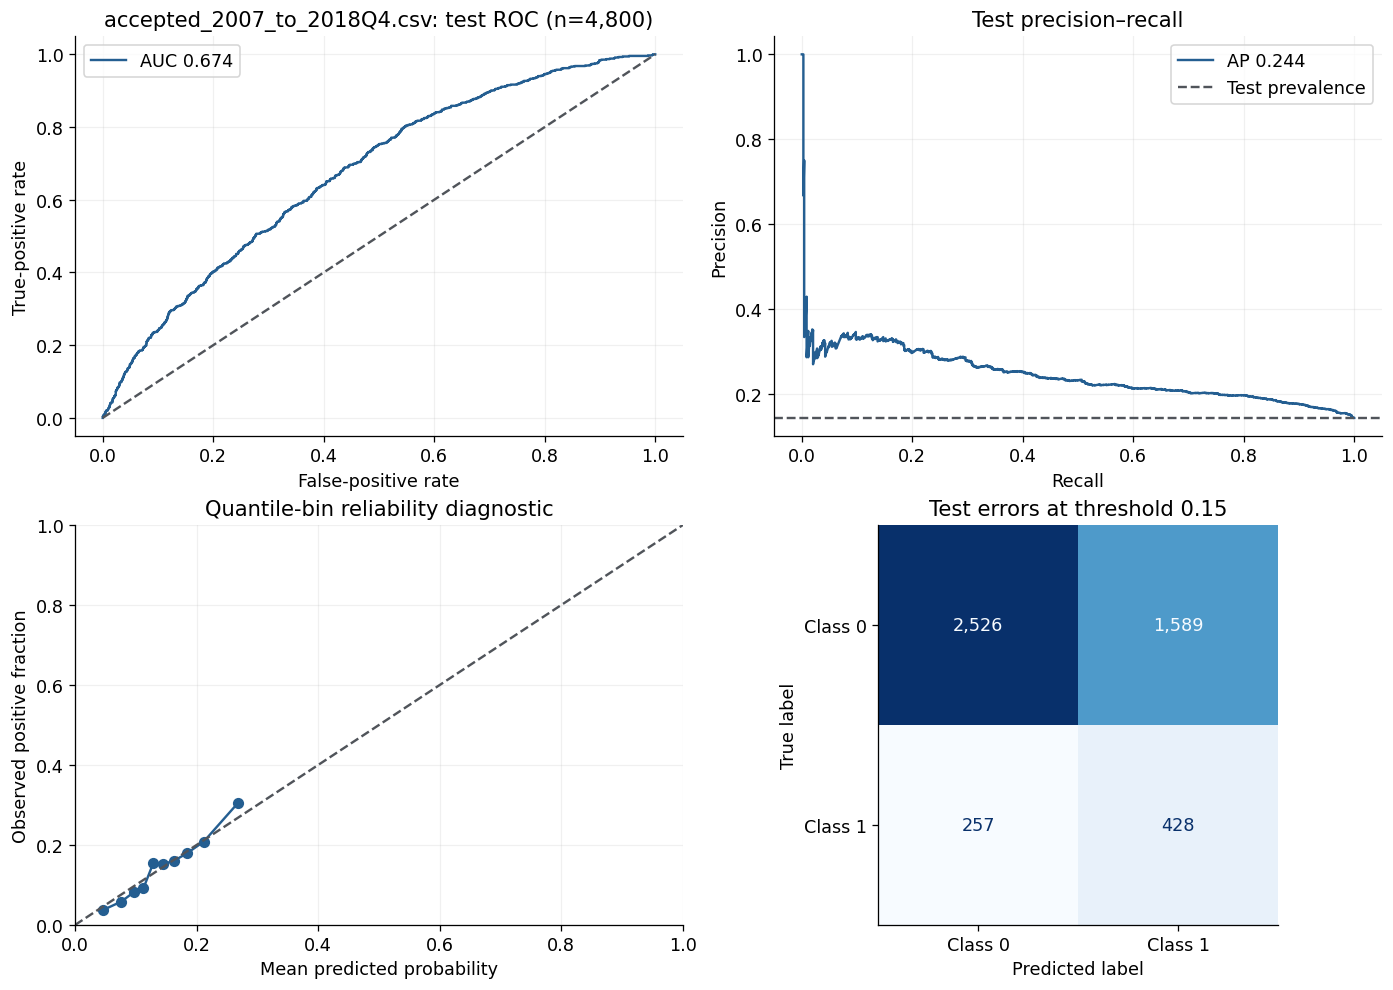

,feature,log-odds coefficient,odds ratio,comparison
2,fico_mid,-0.4113,0.6628,one training SD
9,purpose_credit_card,-0.3489,0.7055,vs reference category
11,purpose_home_improvement,-0.1868,0.8297,vs reference category
1,log_annual_income,-0.1800,0.8353,one training SD
6,home_ownership_MORTGAGE,-0.1583,0.8536,vs reference category
19,purpose_vacation,-0.1477,0.8627,vs reference category
10,purpose_debt_consolidation,-0.1410,0.8684,vs reference category
12,purpose_house,-0.1340,0.8746,vs reference category
16,purpose_other,-0.0553,0.9462,vs reference category
4,revol_util,-0.0514,0.9499,one training SD


home_ownership                  ANY
purpose                         car
verification_status    Not Verified
Name: Reference category, dtype: str

In [19]:
fig,axes=plt.subplots(2,2,figsize=(12,8.5),layout='constrained')
fpr,tpr,_=roc_curve(y_test,probability)
axes[0,0].plot(fpr,tpr,color=BLUE,label=f"AUC {final_scores['ROC AUC']:.3f}")
axes[0,0].plot([0,1],[0,1],'--',color=GRAY)
axes[0,0].set(title=f'{dataset_name}: test ROC (n={len(y_test):,})',
              xlabel='False-positive rate',ylabel='True-positive rate')
axes[0,0].legend()
precision,recall,_=precision_recall_curve(y_test,probability)
axes[0,1].plot(recall,precision,color=BLUE,label=f"AP {final_scores['Average precision']:.3f}")
axes[0,1].axhline(y_test.mean(),color=GRAY,linestyle='--',label='Test prevalence')
axes[0,1].set(title='Test precision–recall',xlabel='Recall',ylabel='Precision')
axes[0,1].legend()
observed,predicted=calibration_curve(y_test,probability,n_bins=3 if len(y_test)<100 else 10,strategy='quantile')
axes[1,0].plot(predicted,observed,'o-',color=BLUE)
axes[1,0].plot([0,1],[0,1],'--',color=GRAY)
axes[1,0].set(title='Quantile-bin reliability diagnostic',xlabel='Mean predicted probability',
              ylabel='Observed positive fraction',xlim=(0,1),ylim=(0,1))
ConfusionMatrixDisplay(matrix,display_labels=['Class 0','Class 1']).plot(
    ax=axes[1,1],cmap='Blues',colorbar=False,values_format=',d')
axes[1,1].grid(False)
axes[1,1].set_title(f'Test errors at threshold {threshold:.2f}')
plt.show()
names=final_model.named_steps['prepare'].get_feature_names_out()
coefficients=pd.DataFrame({'feature':names,'log-odds coefficient':final_model.named_steps['model'].coef_[0]})
coefficients['odds ratio']=np.exp(coefficients['log-odds coefficient'])
numeric_units={'standard':'one training SD','minmax':'one training range','robust':'one training IQR'}
coefficients['comparison']=[numeric_units[selected_scaler] if name in numeric else 'vs reference category' for name in names]
display(coefficients.sort_values('log-odds coefficient'))
if categorical:
    encoder=final_model.named_steps['prepare'].named_transformers_['cat'].named_steps['encode']
    display(pd.Series({name:values[0] for name,values in zip(categorical,encoder.categories_)},name='Reference category'))

### Dataset conclusions — accepted_2007_to_2018Q4.csv

**standard scaling** with **C = 0.1** was selected using training CV and validation log loss. On **4,800** test records, ROC AUC was **0.674**, average precision **0.244**, and log loss **0.387**, compared with baseline log loss **0.410**. Test positive prevalence was **14.3%**.

The validation-selected threshold **0.15** produced precision **21.2%**, recall **62.5%**, and F1 **0.317**. The confusion matrix records **1,589** false positives and **257** false negatives. At C=1, standard scaling took **117** iterations versus **3000** unscaled; convergence status is reported above.

This result conditions on resolved 2015 36-month loans; excluded ongoing or other-status loans cannot be assumed nondefaults. The extract cutoff and borrower dependence remain uncertain. A later-year test and a verified outcome horizon are still needed.

## C. bank_customers.csv — independent analysis

The binary response is **checking account = 1 versus savings/CD = 0**, derived directly from the observed AccountType field. Predictors are age and account tenure. AccountType itself is excluded from predictors. This models account type, not default.

**Date and grain decisions.** Exclude future opening dates, missing/unparseable/partial
birth dates, dates after the reference date, opening before birth, and unrecognized account
types. Year-only birth dates are not converted into invented full dates. Eligibility flags
can overlap. Account openings during childhood are retained because custodial accounts are
possible; product eligibility is not documented. Repeated account IDs stay together in
train/validation/test and CV. IDs are group keys, not numeric predictors.

**Interpretation limit.** The original file has only 100 rows and many invalid dates.
The valid subset is very small and not representative of all records. Exact predictive
scores will be unstable; these models demonstrate the weekly methods on genuine observed
account fields. Derived age and tenure share a reference date; their association can
partly reflect the arithmetic constraint that an account cannot predate birth.
SSNs are excluded at read time and identifiers are never displayed.

### C1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [20]:
dataset_name = 'bank_customers.csv'
source_frame = pd.read_csv(DATA_DIR / dataset_name, usecols=lambda name: name != 'SSN')
AS_OF = pd.Timestamp('2026-09-26')
birth_text = source_frame['BirthDate'].astype('string').str.strip()
partial_birth = birth_text.str.fullmatch(r'\d{4}', na=False)
birth = pd.to_datetime(birth_text.mask(partial_birth), format='mixed', errors='coerce')
opened = pd.to_datetime(source_frame['AccountOpened'], format='mixed', errors='coerce')
valid_type = source_frame['AccountType'].isin(['checking', 'savings', 'cd'])
eligible = (birth.notna() & opened.notna() & birth.le(AS_OF) & opened.le(AS_OF)
            & opened.ge(birth) & valid_type)
# Reason flags overlap; the union, not their sum, determines exclusions.
display(pd.Series({'source records': len(source_frame),
    'missing/invalid/partial birth date': birth.isna().sum(),
    'missing/invalid opening date': opened.isna().sum(),
    'future opening date': opened.gt(AS_OF).sum(),
    'opening before exact birth date': opened.lt(birth).sum(),
    'missing/unrecognized account type': (~valid_type).sum(),
    'eligible records': eligible.sum(), 'excluded union': (~eligible).sum()}, name='Bank eligibility audit'))
frame = source_frame.loc[eligible].copy()
frame['age_years'] = (AS_OF - birth.loc[eligible]).dt.days / 365.25
frame['tenure_years'] = (AS_OF - opened.loc[eligible]).dt.days / 365.25
# Repeated AccountID values are conservatively grouped, even though this file
# does not document whether they represent shared accounts or data-quality issues.
frame['_group'] = frame['AccountID'].astype('string')
frame['_group'] = frame['_group'].fillna(pd.Series(
    ['missing_account_' + str(i) for i in frame.index], index=frame.index))
frame = frame.reset_index(drop=True)
groups = frame['_group']
assert len(frame) >= 20
display(frame['AccountType'].value_counts().rename('eligible records').to_frame())
# BirthDate, CustomerID, AccountID, and SSN are never displayed or used as model features.

outcome_label = 'checking account versus savings/CD'
X = frame[['age_years', 'tenure_years']].copy()
y = frame['AccountType'].eq('checking').astype(int)
numeric, categorical = list(X.columns), []

source records                        100
missing/invalid/partial birth date      3
missing/invalid opening date            1
future opening date                    59
opening before exact birth date         0
missing/unrecognized account type       1
eligible records                       39
excluded union                         61
Name: Bank eligibility audit, dtype: int64

,eligible records
AccountType,
checking,16
savings,15
cd,8


### C2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [21]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=True)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean,account groups
training,24,0.3333,21
validation,7,0.2857,7
test,8,0.7500,8


,Training missing (%)
age_years,0.0000
tenure_years,0.0000


### C3. Inspect this dataset’s class balance and training predictors

Use the declared binary outcome for this CSV. Compare training-class counts and the first predictor’s distributions, while keeping later model fitting separate from evaluation outcomes. The positive class is named in the chart.

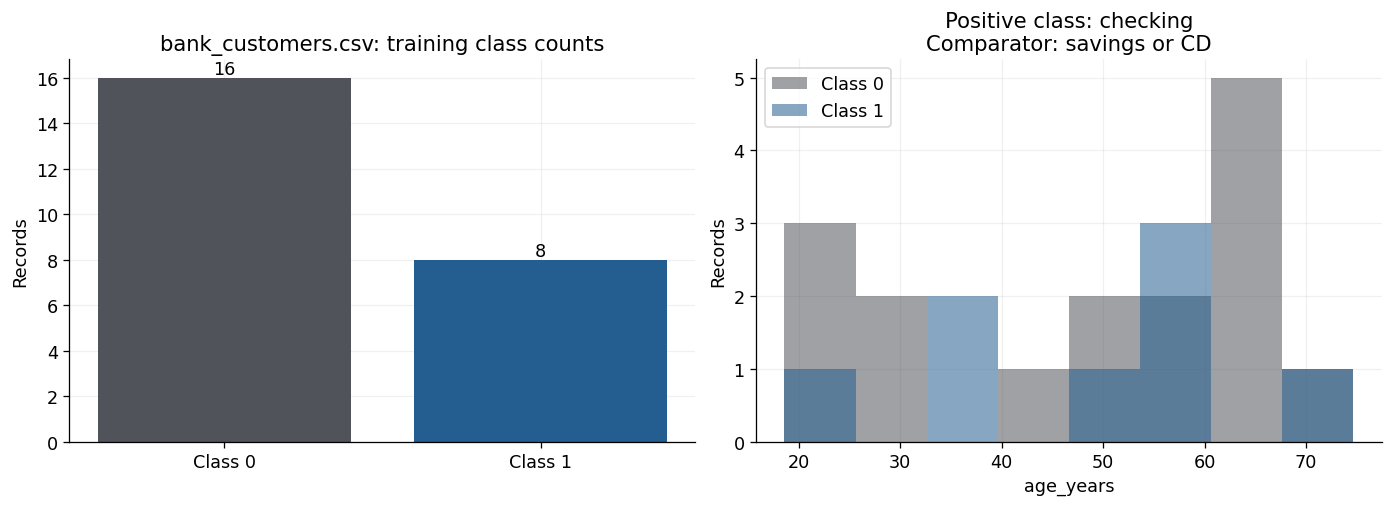

,age_years,tenure_years
min,18.5736,1.3990
median,55.2005,23.3566
max,74.6667,64.1396


In [22]:
counts=y_train.value_counts().reindex([0,1],fill_value=0)
fig,axes=plt.subplots(1,2,figsize=(12,4.3),layout='constrained')
axes[0].bar(['Class 0','Class 1'],counts.to_numpy(),color=[GRAY,BLUE])
for j,count in enumerate(counts):axes[0].text(j,count,str(count),ha='center',va='bottom')
axes[0].set(title=f'{dataset_name}: training class counts',ylabel='Records')
bin_edges = np.histogram_bin_edges(X_train[numeric[0]].dropna(), bins=8 if len(y_train)<100 else 25)
positive_title = ('Positive class: charged off\nResolved 2015, 36-month loans' if dataset_name.startswith('accepted')
                  else 'Positive class: checking\nComparator: savings or CD')
for label,color in [(0,GRAY),(1,BLUE)]:
    axes[1].hist(X_train.loc[y_train.eq(label),numeric[0]],bins=bin_edges,
                 alpha=0.55,color=color,label=f'Class {label}')
axes[1].set(title=positive_title,xlabel=numeric[0],ylabel='Records')
axes[1].legend()
plt.show()
display(X_train[numeric].agg(['min','median','max']))

### C4. Fit logistic regression with four scaling choices

Repeat unscaled, standard, min–max, and robust scaling at the same C = 1, solver, tolerance, and iteration budget. Scaling changes numerical conditioning and the meaning of the L2 penalty. Record convergence rather than suppressing it.

In [23]:
import time
def extra_classifier(scaler,C=1.0):
    return Pipeline([('prepare',extra_preprocessor(numeric,categorical,scaler)),
        ('model',LogisticRegression(C=C,solver='lbfgs',max_iter=3000,tol=1e-6,random_state=SEED))])
fixed={}
scale_rows=[]
for scaler in ['none','standard','minmax','robust']:
    estimator=extra_classifier(scaler)
    started=time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always',ConvergenceWarning)
        estimator.fit(X_train,y_train)
    converged=not any(issubclass(item.category,ConvergenceWarning) for item in caught)
    probability=estimator.predict_proba(X_valid)[:,1]
    fixed[scaler]=estimator
    scale_rows.append({'scaler':scaler,'converged':converged,
        'iterations':int(estimator.named_steps['model'].n_iter_[0]),
        'fit seconds':time.perf_counter()-started,'validation log loss':log_loss(y_valid,probability),
        'validation AUC':roc_auc_score(y_valid,probability)})
scale_results=pd.DataFrame(scale_rows).set_index('scaler')
display(scale_results)
standardized=fixed['standard'].named_steps['prepare'].transform(X_train)[:,:len(numeric)]
display(pd.DataFrame({'standardized training mean':standardized.mean(axis=0),
                      'standardized training SD':standardized.std(axis=0)},index=numeric))
assert np.allclose(standardized.mean(axis=0),0,atol=1e-8)
assert np.allclose(standardized.std(axis=0),1,atol=1e-8)

,converged,iterations,fit seconds,validation log loss,validation AUC
scaler,,,,,
none,True,26,0.0032,0.5729,0.7000
standard,True,7,0.0023,0.5713,0.7000
minmax,True,11,0.0023,0.5893,0.7000
robust,True,7,0.0023,0.5739,0.7000


,standardized training mean,standardized training SD
age_years,-0.0000,1.0000
tenure_years,0.0000,1.0000


### C5. Tune regularization within this dataset’s training folds

Training CV selects C for each scaled pipeline; validation log loss selects the scaler. Bank folds preserve account groups. Do not compare the numeric C or classification scores with another dataset as if its target were the same.

In [24]:
searches={}
rows=[]
for scaler in ['standard','minmax','robust']:
    search=GridSearchCV(extra_classifier(scaler),{'model__C':[0.01,0.1,1.0,10.0]},
        cv=folds,scoring='neg_log_loss',n_jobs=1,error_score='raise').fit(X_train,y_train)
    searches[scaler]=search
    probability=search.predict_proba(X_valid)[:,1]
    rows.append({'scaler':scaler,'C':search.best_params_['model__C'],
        'CV log loss':-search.best_score_,'validation log loss':log_loss(y_valid,probability),
        'validation AUC':roc_auc_score(y_valid,probability),
        'validation average precision':average_precision_score(y_valid,probability)})
validation=pd.DataFrame(rows).set_index('scaler')
display(validation.sort_values('validation log loss'))
selected_scaler=validation['validation log loss'].idxmin()
chosen_model=searches[selected_scaler].best_estimator_
validation_probability=chosen_model.predict_proba(X_valid)[:,1]

,C,CV log loss,validation log loss,validation AUC,validation average precision
scaler,,,,,
standard,0.0100,0.6819,0.6009,0.6000,0.4500
robust,0.0100,0.6796,0.6022,0.6000,0.4500
minmax,0.0100,0.6779,0.6033,0.6000,0.4500


### C6. Select a threshold from this dataset’s validation records

Maximize validation F1 over a prespecified threshold grid. This is an illustrative precision/recall tradeoff, not an optimized financial or customer-contact policy. With only a few bank validation records, the curve changes in large discrete steps.

,threshold,precision,recall,F1
26,0.3100,0.2857,1.0000,0.4444
27,0.3200,0.2857,1.0000,0.4444
28,0.3300,0.3333,1.0000,0.5000
29,0.3400,0.0000,0.0000,0.0000
30,0.3500,0.0000,0.0000,0.0000


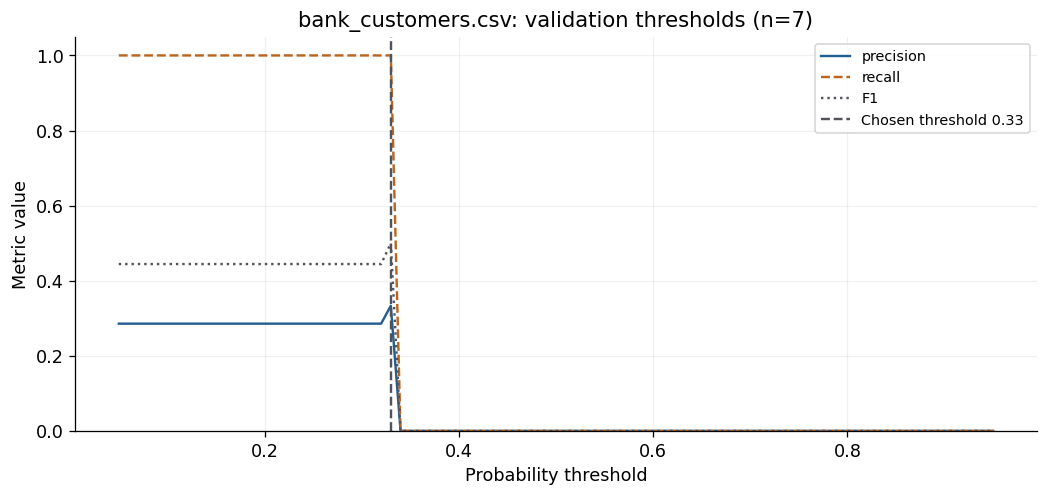

In [25]:
threshold_table=pd.DataFrame([{'threshold':t,
    'precision':precision_score(y_valid,validation_probability>=t,zero_division=0),
    'recall':recall_score(y_valid,validation_probability>=t,zero_division=0),
    'F1':f1_score(y_valid,validation_probability>=t,zero_division=0)}
    for t in np.linspace(0.05,0.95,91)])
threshold=float(threshold_table.loc[threshold_table.F1.idxmax(),'threshold'])
display(threshold_table.loc[(threshold_table.threshold-threshold).abs()<0.021])
fig,ax=plt.subplots(figsize=(9,4.2),layout='constrained')
for name,color,style in [('precision',BLUE,'-'),('recall',ORANGE,'--'),('F1',GRAY,':')]:
    ax.plot(threshold_table.threshold,threshold_table[name],label=name,color=color,linestyle=style)
ax.axvline(threshold,color=GRAY,linestyle='--',label=f'Chosen threshold {threshold:.2f}')
ax.set(title=f'{dataset_name}: validation thresholds (n={len(y_valid):,})',
       xlabel='Probability threshold',ylabel='Metric value',ylim=(0,1.05))
ax.legend(fontsize=9)
plt.show()

### C7. Evaluate probabilities and classifications on this dataset’s test set

Refit the selected pipeline on development data and freeze the validation threshold. Compare against development-prevalence probabilities and the development-majority class. The bank test-class mix may differ sharply from development; show that difference rather than resplitting to improve the score.

In [26]:
final_model=clone(chosen_model).fit(X_dev,y_dev)
probability=final_model.predict_proba(X_test)[:,1]
baseline_probability=np.full(len(y_test),y_dev.mean())
def class_probability_metrics(actual,predicted):
    return {'ROC AUC':roc_auc_score(actual,predicted),
        'Average precision':average_precision_score(actual,predicted),
        'Log loss':log_loss(actual,predicted),'Brier score':brier_score_loss(actual,predicted)}
def class_decision_metrics(actual,predicted):
    return {'Accuracy':accuracy_score(actual,predicted),
        'Balanced accuracy':balanced_accuracy_score(actual,predicted),
        'Precision':precision_score(actual,predicted,zero_division=0),
        'Recall':recall_score(actual,predicted,zero_division=0),
        'F1':f1_score(actual,predicted,zero_division=0)}
final_scores=class_probability_metrics(y_test,probability)
baseline_scores=class_probability_metrics(y_test,baseline_probability)
display(pd.DataFrame([final_scores,baseline_scores],index=[f'Logistic ({selected_scaler})','Development prevalence']))
decisions=class_decision_metrics(y_test,probability>=threshold)
display(pd.DataFrame({
    'Threshold 0.50':class_decision_metrics(y_test,probability>=0.50),
    f'Threshold {threshold:.2f}':decisions,
    'Development-majority baseline':class_decision_metrics(y_test,
        np.full(len(y_test),int(y_dev.mean()>=0.5)))}).T)
matrix=confusion_matrix(y_test,probability>=threshold,labels=[0,1])
assert matrix.sum()==len(y_test) and np.isfinite(probability).all()
display(pd.Series({'development positive share':y_dev.mean(),'test positive share':y_test.mean(),
                   'test records':len(y_test)},name='Evaluation context'))
dataset_results.append({'dataset':dataset_name,'outcome':outcome_label,
    'training n':len(y_train),'test n':len(y_test),'model':f'Logistic ({selected_scaler})',
    **final_scores,'threshold':threshold,'positive share':y_test.mean()})

,ROC AUC,Average precision,Log loss,Brier score
Logistic (standard),0.5000,0.7345,0.9422,0.3686
Development prevalence,0.5000,0.7500,0.9459,0.3702


,Accuracy,Balanced accuracy,Precision,Recall,F1
Threshold 0.50,0.2500,0.5000,0.0000,0.0000,0.0000
Threshold 0.33,0.2500,0.5000,0.0000,0.0000,0.0000
Development-majority baseline,0.2500,0.5000,0.0000,0.0000,0.0000


development positive share   0.3226
test positive share          0.7500
test records                 8.0000
Name: Evaluation context, dtype: float64

### C8. Inspect discrimination, calibration, errors, and coefficients

Repeat all diagnostics for this dataset. The bank reliability curve uses only three bins because its test set is tiny; neither its curve nor its AUC should be interpreted as a precise population estimate. Odds ratios use the selected scaler’s units and remain conditional associations.

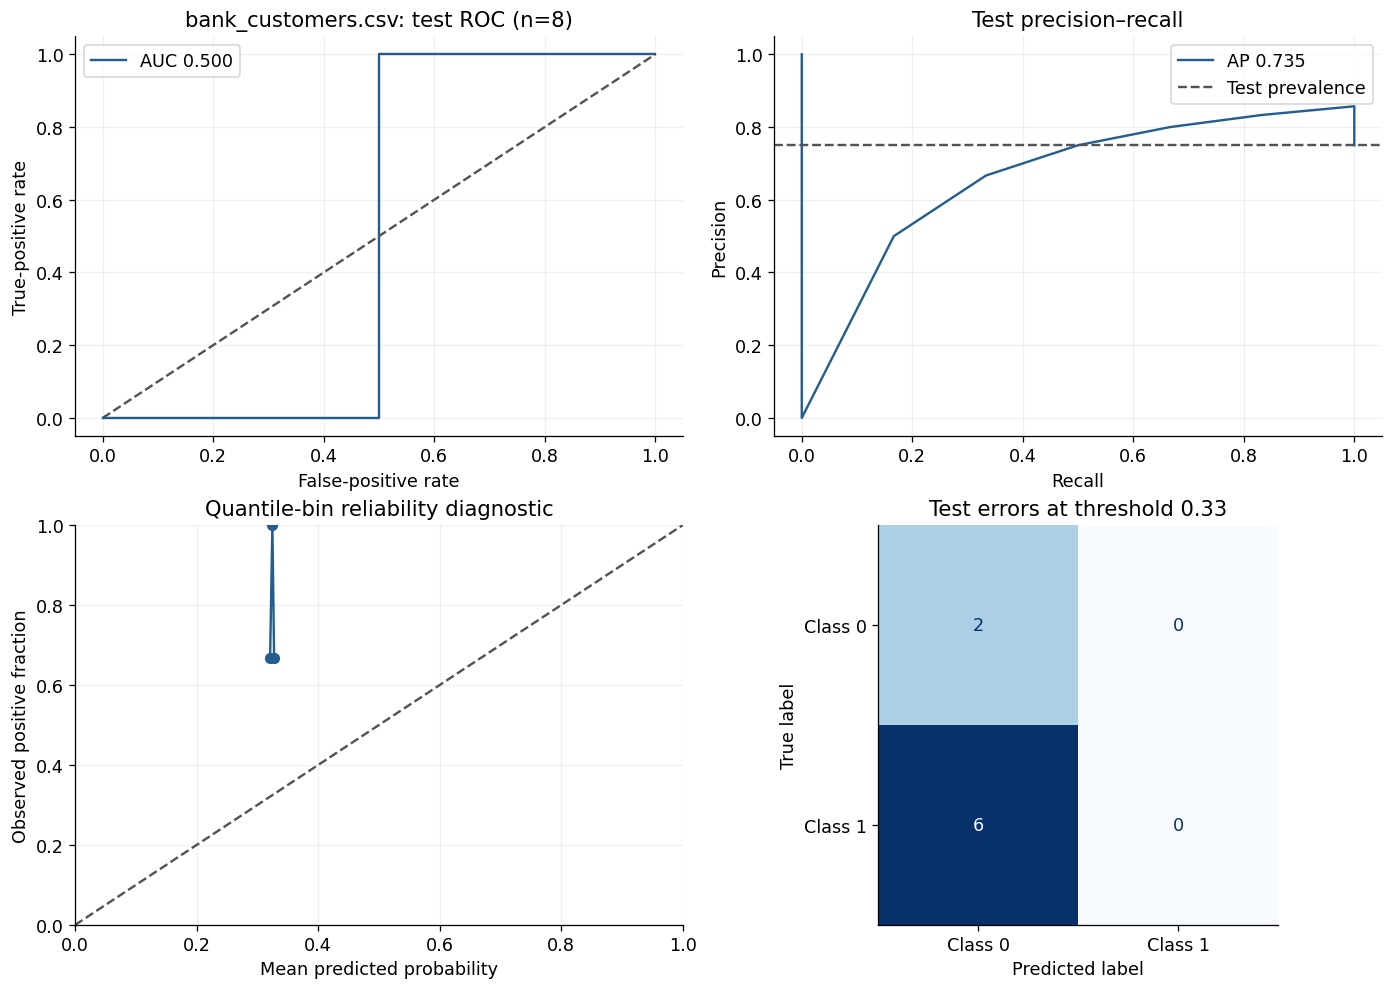

,feature,log-odds coefficient,odds ratio,comparison
1,tenure_years,-0.0264,0.9740,one training SD
0,age_years,0.0008,1.0008,one training SD


In [27]:
fig,axes=plt.subplots(2,2,figsize=(12,8.5),layout='constrained')
fpr,tpr,_=roc_curve(y_test,probability)
axes[0,0].plot(fpr,tpr,color=BLUE,label=f"AUC {final_scores['ROC AUC']:.3f}")
axes[0,0].plot([0,1],[0,1],'--',color=GRAY)
axes[0,0].set(title=f'{dataset_name}: test ROC (n={len(y_test):,})',
              xlabel='False-positive rate',ylabel='True-positive rate')
axes[0,0].legend()
precision,recall,_=precision_recall_curve(y_test,probability)
axes[0,1].plot(recall,precision,color=BLUE,label=f"AP {final_scores['Average precision']:.3f}")
axes[0,1].axhline(y_test.mean(),color=GRAY,linestyle='--',label='Test prevalence')
axes[0,1].set(title='Test precision–recall',xlabel='Recall',ylabel='Precision')
axes[0,1].legend()
observed,predicted=calibration_curve(y_test,probability,n_bins=3 if len(y_test)<100 else 10,strategy='quantile')
axes[1,0].plot(predicted,observed,'o-',color=BLUE)
axes[1,0].plot([0,1],[0,1],'--',color=GRAY)
axes[1,0].set(title='Quantile-bin reliability diagnostic',xlabel='Mean predicted probability',
              ylabel='Observed positive fraction',xlim=(0,1),ylim=(0,1))
ConfusionMatrixDisplay(matrix,display_labels=['Class 0','Class 1']).plot(
    ax=axes[1,1],cmap='Blues',colorbar=False,values_format=',d')
axes[1,1].grid(False)
axes[1,1].set_title(f'Test errors at threshold {threshold:.2f}')
plt.show()
names=final_model.named_steps['prepare'].get_feature_names_out()
coefficients=pd.DataFrame({'feature':names,'log-odds coefficient':final_model.named_steps['model'].coef_[0]})
coefficients['odds ratio']=np.exp(coefficients['log-odds coefficient'])
numeric_units={'standard':'one training SD','minmax':'one training range','robust':'one training IQR'}
coefficients['comparison']=[numeric_units[selected_scaler] if name in numeric else 'vs reference category' for name in names]
display(coefficients.sort_values('log-odds coefficient'))
if categorical:
    encoder=final_model.named_steps['prepare'].named_transformers_['cat'].named_steps['encode']
    display(pd.Series({name:values[0] for name,values in zip(categorical,encoder.categories_)},name='Reference category'))

### Dataset conclusions — bank_customers.csv

**standard scaling** with **C = 0.01** was selected using training CV and validation log loss. On **8** test records, ROC AUC was **0.500**, average precision **0.735**, and log loss **0.942**, compared with baseline log loss **0.946**. Test positive prevalence was **75.0%**.

The validation-selected threshold **0.33** produced precision **0.0%**, recall **0.0%**, and F1 **0.000**. The confusion matrix records **0** false positives and **6** false negatives. At C=1, standard scaling took **7** iterations versus **26** unscaled; convergence status is reported above.

The eight-record bank test set has a different class mix from development. Its AUC, calibration bins, and threshold metrics are too unstable for operational claims. The target is account type, not a loan event, and the eligibility filter excludes many source records.

## Method references

- [scikit-learn: linear models](https://scikit-learn.org/stable/modules/linear_model.html)
- [scikit-learn: preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [scikit-learn: feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)
- [scikit-learn: PCR versus PLS](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Dataset observations in this notebook come from the local CSV files; the links explain methods, not dataset provenance. The original assignment text is preserved above. Its omitted Milestone One rubric/link still needs to be checked before final submission.

### Reconcile coverage across the three datasets

Each row comes from a separately fitted workflow above. Response units and sample sizes are retained to prevent false comparisons between different tasks.

In [28]:
all_dataset_results = pd.DataFrame(dataset_results).set_index('dataset')
assert set(all_dataset_results.index) == {
    'accepted_2007_to_2018Q4.csv','Loan_Default.csv','bank_customers.csv'}
with pd.option_context('display.max_columns',None,'display.max_colwidth',75):
    display(all_dataset_results)

,outcome,training n,test n,model,ROC AUC,Average precision,Log loss,threshold,positive share,Brier score
dataset,,,,,,,,,,
Loan_Default.csv,recorded Status 1,89202,29734,Logistic (Min-max),0.5890,0.3276,0.5512,0.2300,0.2465,NaN
accepted_2007_to_2018Q4.csv,charged off among resolved 2015 36-month loans,14400,4800,Logistic (standard),0.6737,0.2443,0.3867,0.1500,0.1427,0.1168
bank_customers.csv,checking account versus savings/CD,24,8,Logistic (standard),0.5000,0.7345,0.9422,0.3300,0.7500,0.3686


## Overall conclusions

- **Loan_Default.csv** — recorded Status 1: test AUC **0.589**, average precision **0.328**, log loss **0.551**, test n = **29,734**; validation-selected threshold **0.23**.
- **accepted_2007_to_2018Q4.csv** — charged off among resolved 2015 36-month loans: test AUC **0.674**, average precision **0.244**, log loss **0.387**, test n = **4,800**; validation-selected threshold **0.15**.
- **bank_customers.csv** — checking account versus savings/CD: test AUC **0.500**, average precision **0.735**, log loss **0.942**, test n = **8**; validation-selected threshold **0.33**.

All three datasets now have independent logistic-regression and feature-scaling analyses. The positive classes are different and must not be interpreted as a common default outcome. The mortgage file has an undocumented status definition, LendingClub evaluation conditions on resolved 2015 36-month loans, and the bank target is checking account type in a very small date-valid subset. Scaling and threshold comparisons demonstrate method behavior; they do not justify lending decisions or deployment.